In [ ]:
import os
import gdown
import zipfile
from google.colab import drive

# Подключаем Google Диск
drive.mount('/content/drive')

# Указываем путь к папке, где будут распакованы архивы
IMAGE_PATH = '/content/pref/'

# Создаем папку, если она не существует
if not os.path.exists(IMAGE_PATH):
    os.makedirs(IMAGE_PATH)

# Список ссылок на архивы и соответствующие имена папок
urls = [
    ('https://drive.google.com/uc?id=10qG4XE2nyUBBXPXGGoEQTx1GSYJBbu59', 'vozd_puz'),
    ('https://drive.google.com/uc?id=1zG83stcXAXF4LYkurayhT4Om8Us8P5UT', 'prigar'),
    ('https://drive.google.com/uc?id=1UPEkUIxxm1J_mFpfUs1_4asJ-PBbl60L', 'chern_toch')
]

# Загрузка и распаковка архивов
for url, folder_name in urls:
    # Создаем папку для каждого архива
    folder_path = os.path.join(IMAGE_PATH, folder_name)
    if not os.path.exists(folder_path):
        os.makedirs(folder_path)

    # Получаем имя файла из URL
    output = os.path.join(folder_path, folder_name + '.zip')

    # Загружаем архив
    gdown.download(url, output, quiet=False)

    # Распаковываем архив
    with zipfile.ZipFile(output, 'r') as zip_ref:
        zip_ref.extractall(folder_path)

# Проверяем содержимое папки
print(os.listdir(IMAGE_PATH))

Mounted at /content/drive


Downloading...
From (original): https://drive.google.com/uc?id=10qG4XE2nyUBBXPXGGoEQTx1GSYJBbu59
From (redirected): https://drive.google.com/uc?id=10qG4XE2nyUBBXPXGGoEQTx1GSYJBbu59&confirm=t&uuid=2f92fc92-8c44-4b29-9ed6-3b3e1e831371
To: /content/pref/vozd_puz/vozd_puz.zip
100%|██████████| 1.03G/1.03G [00:17<00:00, 58.0MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1zG83stcXAXF4LYkurayhT4Om8Us8P5UT
From (redirected): https://drive.google.com/uc?id=1zG83stcXAXF4LYkurayhT4Om8Us8P5UT&confirm=t&uuid=37a7b753-0317-447d-8666-b1c444c7ed74
To: /content/pref/prigar/prigar.zip
100%|██████████| 1.08G/1.08G [00:14<00:00, 72.3MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1UPEkUIxxm1J_mFpfUs1_4asJ-PBbl60L
From (redirected): https://drive.google.com/uc?id=1UPEkUIxxm1J_mFpfUs1_4asJ-PBbl60L&confirm=t&uuid=ada43e94-3583-47fb-95b5-4245c91b6017
To: /content/pref/chern_toch/chern_toch.zip
100%|██████████| 1.03G/1.03G [00:08<00:00, 120MB/s]


['chern_toch', 'prigar', 'vozd_puz']


In [ ]:
import shutil

# Определяем пути к исходным и целевым папкам
source_path_vozd_puz = '/content/pref/vozd_puz/vozd_puz/'
target_path_vozd_puz = '/content/pref/vozd_puz/'

# Перемещение изображений из старых папок в новые
for file_name in os.listdir(source_path_vozd_puz):
    shutil.move(os.path.join(source_path_vozd_puz, file_name), target_path_vozd_puz)

# Удаление лишних папок
shutil.rmtree(os.path.dirname(source_path_vozd_puz))  # Удаляем папку vozd_puz с содержимым

print("Изображения перемещены, лишние папки удалены.")

Изображения перемещены, лишние папки удалены.


In [ ]:
# методы для отрисовки изображений
from PIL import Image

# Для отрисовки графиков
import matplotlib.pyplot as plt

# Для генерации случайных чисел
import random

# Библиотека работы с массивами
import numpy as np

# для разделения выборок
from sklearn.model_selection import train_test_split

# для создания сети
from tensorflow.keras.models import Sequential

# для создания слоев
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout, BatchNormalization

# для работы с изображениями
from tensorflow.keras.preprocessing import image

# оптимизатор
from tensorflow.keras.optimizers import Adam

# модуль для отсчета времени
import time

In [ ]:
# Указываем пути к файлам
files_to_delete = [
    '/content/pref/vozd_puz/vozd_puz.zip',
    '/content/pref/prigar/prigar.zip',
    '/content/pref/chern_toch/chern_toch.zip'
]

# Удаляем файлы
for file_path in files_to_delete:
    try:
        os.remove(file_path)
        print(f'Файл {file_path} успешно удален.')
    except FileNotFoundError:
        print(f'Файл {file_path} не найден.')
    except Exception as e:
        print(f'Ошибка при удалении файла {file_path}: {e}')

Файл /content/pref/vozd_puz/vozd_puz.zip успешно удален.
Файл /content/pref/prigar/prigar.zip успешно удален.
Файл /content/pref/chern_toch/chern_toch.zip успешно удален.


In [ ]:
# Получение списка папок, находящемуся по адресу в скобках
os.listdir(IMAGE_PATH)

['chern_toch', 'prigar', 'vozd_puz']

In [ ]:
# Определение списка имен классов
CLASS_LIST = sorted(os.listdir(IMAGE_PATH))

# Определение количества классов
CLASS_COUNT = len(CLASS_LIST)

# Проверка результата
print(f'Количество классов: {CLASS_COUNT}, метки классов: {CLASS_LIST}')

Количество классов: 3, метки классов: ['chern_toch', 'prigar', 'vozd_puz']


In [ ]:
# Получения списка файлов для каждого класса

for cls in CLASS_LIST:
    print(cls, ':', os.listdir(f'{IMAGE_PATH}{cls}/'))

chern_toch : ['aug_0_9080.bmp', 'aug_0_4758.bmp', 'aug_0_2747.bmp', 'aug_0_2814.bmp', 'aug_0_5191.bmp', 'aug_0_7212.bmp', 'aug_0_7016.bmp', 'aug_0_1746.bmp', 'HT-SUA501GC-T1V-C-Snapshot-20250823-133330-767-443736879935.BMP', 'aug_0_2207.bmp', 'aug_0_9526.bmp', 'HT-SUA501GC-T1V-C-Snapshot-20250823-133218-636-443015569014.BMP', 'aug_0_2253.bmp', 'aug_0_4059.bmp', 'aug_0_3279.bmp', 'HT-SUA501GC-T1V-C-Snapshot-20250823-133107-343-442302643404.BMP', 'aug_0_6628.bmp', 'aug_0_4198.bmp', 'aug_0_8032.bmp', 'aug_0_9094.bmp', 'aug_0_1070.bmp', 'aug_0_8376.bmp', 'aug_0_1577.bmp', 'aug_0_6412.bmp', 'aug_0_4181.bmp', 'aug_0_421.bmp', 'aug_0_8141.bmp', 'aug_0_8556.bmp', 'aug_0_6168.bmp', 'aug_0_2106.bmp', 'aug_0_5447.bmp', 'HT-SUA501GC-T1V-C-Snapshot-20250823-133458-014-444609351673.BMP', 'aug_0_5694.bmp', 'aug_0_1613.bmp', 'aug_0_936.bmp', 'HT-SUA501GC-T1V-C-Snapshot-20250823-133119-521-442424428166.BMP', 'aug_0_4731.bmp', 'HT-SUA501GC-T1V-C-Snapshot-20250823-133707-543-445904641747.BMP', 'aug_0_199

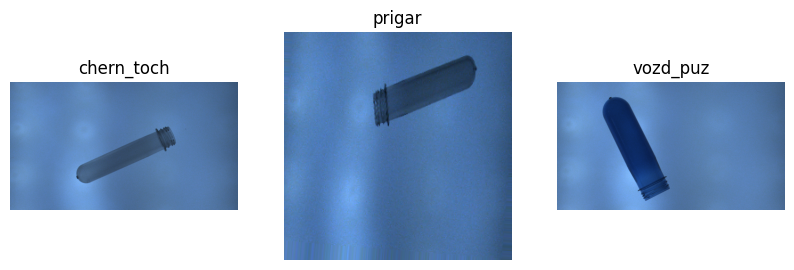

In [ ]:
# Создание заготовки для изображений всех классов
fig, axs = plt.subplots(1, CLASS_COUNT, figsize=(10, 5))

# Для всех номеров классов:
for i in range(CLASS_COUNT):

    # Формирование пути к папке содержимого класса
    car_path = f'{IMAGE_PATH}{CLASS_LIST[i]}/'

    # Выбор случайного фото из i-го класса
    img_path = car_path + random.choice(os.listdir(car_path))

    # Отображение фотографии (подробнее будет объяснено далее)
    axs[i].set_title(CLASS_LIST[i])
    axs[i].imshow(Image.open(img_path))
    axs[i].axis('off')

# Отрисовка всего полотна
plt.show()

In [ ]:
data_files = []                           # Cписок путей к файлам картинок
data_labels = []                          # Список меток классов, соответствующих файлам

for class_label in range(CLASS_COUNT):    # Для всех классов по порядку номеров (их меток)
    class_name = CLASS_LIST[class_label]  # Выборка имени класса из списка имен
    class_path = IMAGE_PATH + class_name  # Формирование полного пути к папке с изображениями класса
    class_files = os.listdir(class_path)  # Получение списка имен файлов с изображениями текущего класса
    print(f'Размер класса {class_name} составляет {len(class_files)} фото')

    # Добавление к общему списку всех файлов класса с добавлением родительского пути
    data_files += [f'{class_path}/{file_name}' for file_name in class_files]

    # Добавление к общему списку меток текущего класса - их ровно столько, сколько файлов в классе
    data_labels += [class_label] * len(class_files)

print()
print('Общий размер базы для обучения:', len(data_labels))

Размер класса chern_toch составляет 870 фото
Размер класса prigar составляет 911 фото
Размер класса vozd_puz составляет 210 фото

Общий размер базы для обучения: 1991


In [ ]:
# Задание единых размеров изображений
IMG_WIDTH = 128                           # Ширина изображения
IMG_HEIGHT = 64                           # Высота изображения

In [ ]:
# перевод изображений в тензоры
data_images = []                          # Пустой список для данных изображений

for file_name in data_files:
    # Открытие и смена размера изображения
    img = Image.open(file_name).resize((IMG_WIDTH, IMG_HEIGHT))
    img_np = np.array(img)                # Перевод в numpy-массив
    data_images.append(img_np)            # Добавление изображения в виде numpy-массива к общему списку

x_data = np.array(data_images)            # Перевод общего списка изображений в numpy-массив
y_data = np.array(data_labels)            # Перевод общего списка меток класса в numpy-массив

print(f'В массив собрано {len(data_images)} фотографий следующей формы: {img_np.shape}')
print(f'Общий массив данных изображений следующей формы: {x_data.shape}')
print(f'Общий массив меток классов следующей формы: {y_data.shape}')

В массив собрано 1991 фотографий следующей формы: (64, 128, 3)
Общий массив данных изображений следующей формы: (1991, 64, 128, 3)
Общий массив меток классов следующей формы: (1991,)


array([[[ 57,  94, 140],
        [ 57,  94, 140],
        [ 57,  94, 140],
        ...,
        [ 46,  81, 126],
        [ 45,  81, 126],
        [ 44,  79, 123]],

       [[ 55,  95, 148],
        [ 55,  95, 148],
        [ 55,  95, 148],
        ...,
        [ 46,  82, 125],
        [ 46,  80, 123],
        [ 45,  79, 122]],

       [[ 57,  96, 145],
        [ 57,  96, 145],
        [ 57,  96, 146],
        ...,
        [ 45,  81, 128],
        [ 45,  79, 125],
        [ 44,  78, 126]],

       ...,

       [[ 74, 117, 181],
        [ 77, 123, 184],
        [ 81, 129, 193],
        ...,
        [ 54,  88, 122],
        [ 54,  88, 122],
        [ 54,  88, 122]],

       [[ 75, 118, 182],
        [ 77, 123, 185],
        [ 82, 129, 194],
        ...,
        [ 53,  87, 135],
        [ 53,  87, 134],
        [ 53,  87, 134]],

       [[ 75, 118, 183],
        [ 77, 124, 185],
        [ 83, 129, 194],
        ...,
        [ 52,  87, 134],
        [ 52,  87, 135],
        [ 52,  87, 136]]], dtype=uint8)
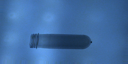

In [ ]:
# вывод первого изображения (трехмерный тензор)
x_data[0]

In [ ]:
# Создание модели последовательной архитектуры
model = Sequential()

In [ ]:
# Первый сверточный блок
model.add(Conv2D(256, (3, 3), name='First_C', padding='same', activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)))  # (64,128,3) --> (64,128,256) меняется кол-во фильтров
model.add(BatchNormalization(name='First_B'))  # (64,128,256) --> (64,128,256) нет изменений

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Второй сверточный блок
model.add(Conv2D(256, (3, 3), name='Second_C', padding='same', activation='relu'))  # (64,128,256) --> (64,128,256) нет изменений
model.add(MaxPooling2D(pool_size=(3, 3), name='Second_M'))  # сжимает размер в три раза, с потерей, т.к. padding='valid', глубина не изм. (64,128,256) --> (21,42,256)

In [ ]:
# Третий сверточный блок
model.add(Conv2D(256, (3, 3), name='Third_C', padding='same', activation='relu'))  # (21,42,256) --> (21,42,256) нет изменений
model.add(BatchNormalization(name='Third_B'))  # (21,42,256) --> (21,42,256) нет изменений
model.add(Dropout(0.2, name='Third_D'))  # (21,42,256) --> (21,42,256) нет изменений

In [ ]:
# Четвертый сверточный блок
model.add(Conv2D(256, (3, 3), name='Fourth_F_Unique', padding='same', activation='relu'))  # (21,42,256) --> (21,42,256) нет изменений
model.add(MaxPooling2D(pool_size=(3, 3), name='Fourth_M_Unique'))  # сжимает размер в три раза, хотя padding='valid', потерь нет, т.к. делится кратно, глубина не изм. (21,42,256) --> (7,14,256)
model.add(Dropout(0.2, name='Fourth_D_Unique'))  # (7,14,256) --> (7,14,256) нет изменений

In [ ]:
# Пятый сверточный блок
model.add(Conv2D(512, (3, 3), name='Fifth_D', padding='same', activation='relu'))  # (7,14,256) --> (7,14,512) меняется количество фильтров
model.add(BatchNormalization(name='Fifth_B'))  # (7,14,512) --> (7,14,512) нет изменений

In [ ]:
# Шестой сверточный блок
model.add(Conv2D(1024, (3, 3), name='Sixth_C', padding='same', activation='relu'))  # (7,14,1024) --> (7,14,1024) меняется кол-во фильтров
model.add(MaxPooling2D(pool_size=(3, 3), name='Sixth_M'))  # сжимает размер в три раза, с потерей, т.к. padding='valid', глубина не изм. (7,14,1024) --> (2,4,1024)
model.add(Dropout(0.2, name='Sixth_D'))  # (2,4,1024) --> (2,4,1024) нет изменений

In [ ]:
# Блок классификации
model.add(Flatten(name='Class_11'))  # слой преобразования многомерных данных в одномерные (2,4,1024) --> (2*4*1024) --> (8192)
model.add(Dense(2048, activation='relu', name='Class_12'))  # полносвязный слой, меняется кол-во нейронов (8192) --> (2048)
# model.add(Dense(4096, activation='relu', name='Class_3'))  # полносвязный слой, меняется кол-во нейронов (2048) --> (4096)
model.add(Dense(CLASS_COUNT, activation='softmax', name='Class_13'))  # выходной полносвязный слой, кол-во нейронов = количество классов (4096) --> (3)

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ First_C (Conv2D)                │ (None, 64, 128, 256)   │         7,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ First_B (BatchNormalization)    │ (None, 64, 128, 256)   │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Second_C (Conv2D)               │ (None, 64, 128, 256)   │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Second_M (MaxPooling2D)         │ (None, 21, 42, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Third_C (Conv2D)                │ (None, 21, 42, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Third_B (BatchNormalization)    │ (None, 21, 42, 256)    │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Third_D (Dropout)               │ (None, 21, 42, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Fourth_F_Unique (Conv2D)        │ (None, 21, 42, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Fourth_M_Unique (MaxPooling2D)  │ (None, 7, 14, 256)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Fourth_D_Unique (Dropout)       │ (None, 7, 14, 256)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Fifth_D (Conv2D)                │ (None, 7, 14, 512)     │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Fifth_B (BatchNormalization)    │ (None, 7, 14, 512)     │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Sixth_C (Conv2D)                │ (None, 7, 14, 1024)    │     4,719,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Sixth_M (MaxPooling2D)          │ (None, 2, 4, 1024)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Sixth_D (Dropout)               │ (None, 2, 4, 1024)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Class_11 (Flatten)              │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Class_12 (Dense)                │ (None, 2048)           │    16,779,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Class_13 (Dense)                │ (None, 3)              │         6,147 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,466,691 (93.33 MB)

 Trainable params: 24,464,643 (93.33 MB)

 Non-trainable params: 2,048 (8.00 KB)

In [ ]:
from keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from keras.optimizers import Adam
from sklearn.model_selection import train_test_split

# Компиляция модели
model.compile(loss='sparse_categorical_crossentropy', optimizer=Adam(learning_rate=0.0001), metrics=['accuracy'])

In [ ]:
# Разделение данных на обучающую и тестовую выборки
x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.2, random_state=42)

In [ ]:
# Определение колбэков
model_checkpoint = ModelCheckpoint(filepath='model_best.h5', monitor='val_loss', save_best_only=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.6, patience=2, verbose=1)

In [ ]:
# Обучение модели и сохранение истории
history = model.fit(x_train,  # Обучающая выборка
                    y_train,  # Метки обучающей выборки
                    validation_data=(x_test, y_test),  # Тестовая выборка для валидации
                    shuffle=True,
                    batch_size=25,
                    epochs=30,
                    verbose=1,
                    callbacks=[model_checkpoint, reduce_lr])  # Добавление колбэков

Epoch 1/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 376ms/step - accuracy: 0.4806 - loss: 3.7612
Epoch 1: val_loss improved from inf to 3.05911, saving model to model_best.h5


64/64 ━━━━━━━━━━━━━━━━━━━━ 64s 652ms/step - accuracy: 0.4823 - loss: 3.7357 - val_accuracy: 0.0927 - val_loss: 3.0591 - learning_rate: 1.0000e-04
Epoch 2/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.7797 - loss: 0.4672
Epoch 2: val_loss improved from 3.05911 to 0.68024, saving model to model_best.h5


64/64 ━━━━━━━━━━━━━━━━━━━━ 13s 196ms/step - accuracy: 0.7799 - loss: 0.4669 - val_accuracy: 0.5739 - val_loss: 0.6802 - learning_rate: 1.0000e-04
Epoch 3/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 0.8402 - loss: 0.3520
Epoch 3: val_loss did not improve from 0.68024
64/64 ━━━━━━━━━━━━━━━━━━━━ 11s 176ms/step - accuracy: 0.8401 - loss: 0.3522 - val_accuracy: 0.5564 - val_loss: 0.9471 - learning_rate: 1.0000e-04
Epoch 4/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.8576 - loss: 0.3359
Epoch 4: val_loss did not improve from 0.68024

Epoch 4: ReduceLROnPlateau reducing learning rate to 5.999999848427251e-05.
64/64 ━━━━━━━━━━━━━━━━━━━━ 12s 181ms/step - accuracy: 0.8573 - loss: 0.3365 - val_accuracy: 0.5865 - val_loss: 0.8589 - learning_rate: 1.0000e-04
Epoch 5/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.9069 - loss: 0.2111
Epoch 5: val_loss did not improve from 0.68024
64/64 ━━━━━━━━━━━━━━━━━━━━ 11s 179ms/step - accuracy: 0.9066 - loss: 0.2116 - val_accu

64/64 ━━━━━━━━━━━━━━━━━━━━ 16s 255ms/step - accuracy: 0.9881 - loss: 0.0559 - val_accuracy: 0.8095 - val_loss: 0.5115 - learning_rate: 7.7760e-06
Epoch 14/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.9883 - loss: 0.0453
Epoch 14: val_loss did not improve from 0.51154
64/64 ━━━━━━━━━━━━━━━━━━━━ 11s 174ms/step - accuracy: 0.9882 - loss: 0.0454 - val_accuracy: 0.7644 - val_loss: 0.7443 - learning_rate: 7.7760e-06
Epoch 15/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 0.9871 - loss: 0.0459
Epoch 15: val_loss did not improve from 0.51154

Epoch 15: ReduceLROnPlateau reducing learning rate to 4.665599772124551e-06.
64/64 ━━━━━━━━━━━━━━━━━━━━ 11s 176ms/step - accuracy: 0.9871 - loss: 0.0460 - val_accuracy: 0.7820 - val_loss: 0.6618 - learning_rate: 7.7760e-06
Epoch 16/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.9886 - loss: 0.0483
Epoch 16: val_loss did not improve from 0.51154
64/64 ━━━━━━━━━━━━━━━━━━━━ 11s 177ms/step - accuracy: 0.9885 - loss: 0.0482 - v

In [ ]:
scores = model.evaluate(x_data,
                        y_data,
                        verbose=1
                        )
print('Процент верных ответов на тестовых данных:', round(scores[1],2) * 100, '%')

63/63 ━━━━━━━━━━━━━━━━━━━━ 17s 159ms/step - accuracy: 0.9426 - loss: 0.1299
Процент верных ответов на тестовых данных: 88.0 %


In [ ]:
# Оценка модели на тестовой выборке
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=1)

print(f'Тестовая точность: {test_accuracy:.4f}')
print(f'Тестовая потеря: {test_loss:.4f}')

13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 432ms/step - accuracy: 0.8133 - loss: 0.5598
Тестовая точность: 0.8221
Тестовая потеря: 0.5277


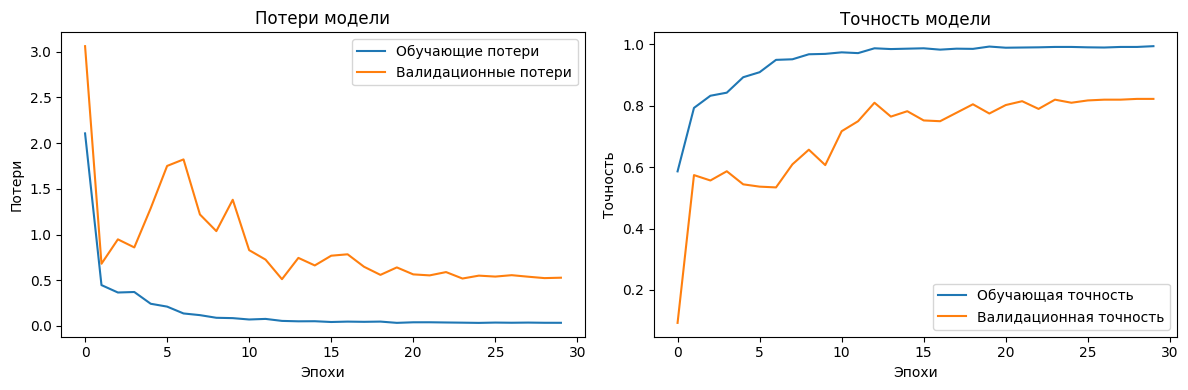

In [ ]:
# Визуализация процесса обучения
plt.figure(figsize=(12, 4))

# График потерь
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Обучающие потери')
plt.plot(history.history['val_loss'], label='Валидационные потери')
plt.title('Потери модели')
plt.xlabel('Эпохи')
plt.ylabel('Потери')
plt.legend()

# График точности
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Обучающая точность')
plt.plot(history.history['val_accuracy'], label='Валидационная точность')
plt.title('Точность модели')
plt.xlabel('Эпохи')
plt.ylabel('Точность')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Получение предсказаний
predictions = model.predict(x_test)

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 122ms/step


In [ ]:
# Определение класса с максимальной вероятностью для каждого изображения
predicted_classes = np.argmax(predictions, axis=1)

In [ ]:
# Выбор одного изображения из каждого класса
unique_classes = np.unique(predicted_classes)
images_per_class = []
for cls in unique_classes:
    class_indices = np.where(predicted_classes == cls)[0]
    if len(class_indices) > 0:
        images_per_class.append(x_test[class_indices[0]])

In [ ]:
# После завершения обучения модели
model.save('my_model.keras')